<div style="
background-color:#EAEAEA;
padding:20px;
border-left:5px solid #6C757D;
border-radius:6px;">

<table style="width:100%; border:none;">
<tr style="border:none;">

<td style="border:none; vertical-align:top;">

<h1 style="font-size:32px; margin-top:0;">
Master's Thesis
</h1>

<hr style="margin:16px 0 22px 0;">

<p style="font-size:22px; line-height:1.5; margin:0;">
<strong>Master's Degree in Advanced Physics</strong> - 
<strong>Universitat de Val?ncia</strong>
</p>

<p style="font-size:17px; margin-top:28px; margin-bottom:6px;">
This notebook is part of the <strong>Master's Thesis (MSc Dissertation)</strong>:
</p>

<div style="
font-size:25px;
font-weight:700;
line-height:1.3;
margin-top:14px;
margin-bottom:26px;">
Fast Simulation of Neutrino Oscillations in Matter
</div>

<p style="font-size:14px; line-height:1.55;">
<strong>Author</strong><br>
Juan Ramon Diaz Santos - 
<a href="mailto:diazjuan@alumni.uv.es">diazjuan@alumni.uv.es</a>
</p>

<p style="font-size:14px; line-height:1.55;">
<strong>Supervisors</strong><br>
Roberto Ruiz de Austri Bazan ?
<a href="mailto:rruiz@ific.uv.es">rruiz@ific.uv.es</a><br>
Michele Lucente ?
<a href="mailto:michele.lucente@unibo.it">michele.lucente@unibo.it</a>
</p>

<p style="font-size:14px; line-height:1.55; margin-bottom:0;">
<strong>Date</strong><br>
September 2026
</p>

</td>

<td style="
border:none;
width:230px;
padding-left:25px;
text-align:right;
vertical-align:top;">

<img src="../../logo_uv.png"
     alt="Universitat de Val?ncia"
     style="width:200px; margin-top:5px;">

</td>

</tr>
</table>

</div>

# SNO EDA v2 - NC and Day/Night PRL Data
---

This notebook is an Exploratory Data Analysis (EDA) of the Sudbury Neutrino
Observatory (SNO) public data files, downloaded from the
**[SNO NC and Day/Night PRL Data page](https://sno.phy.queensu.ca/sno/prlwebpage/)**
and stored locally under `data/external/SNO`.

This is a revised version of `SNO_EDA.ipynb`. Two things changed:

1. **Bug fix**: the v1 notebook's Markdown cells were generated with non-raw
   Python string literals, which silently corrupted LaTeX macros containing
   `\f` and `\t` (`\frac` lost its leading `\f`, and `\theta` had `\t`
   swallowed as a literal tab character) -- the same class of bug found and
   fixed elsewhere in this project's notebooks this session. This notebook is
   built from raw-string cell sources to avoid it.
2. **New analysis**: the energy binning in the SNO spectra/background tables
   is *not* uniform -- the last bin spans 13-20 MeV, 14 times wider than every
   other 0.5 MeV bin. v1 only ever plotted raw counts and livetime-normalized
   rates, both of which make that wide bin look artificially small relative
   to its true differential rate. Sections 4.1 and 5.2 below add the
   bin-width-normalized differential rate (events / day / MeV), and Section 6
   adds a shape-only (unit-area-normalized) day-vs-night spectral comparison
   that is insensitive to the day/night exposure difference.

---

## Table of Contents

| # | Section |
|---|---------|
| [0](#0.-Dataset-and-Physics-Context) | **Dataset and Physics Context**: source, files, physics, references |
| [1](#1.-Libraries) | **Libraries** |
| [2](#2.-Paths-and-Configuration) | **Paths and Configuration** |
| [3](#3.-Raw-Data-Inventory) | **Raw Data Inventory** |
| [4](#4.-Day-and-Night-Energy-Spectra-and-Asymmetry) | **Day and Night Energy Spectra and Asymmetry**: counts, rates, differential rate (4.1), bin-wise asymmetry (4.2) |
| [5](#5.-Background-Tables-and-Signal-Estimate) | **Background Tables and Signal Estimate**: background components (5.1), background-subtracted rate (5.2) |
| [6](#6.-Combined-Spectrum-and-Shape-Comparison) | **Combined Spectrum and Shape Comparison** |
| [7](#7.-Livetime-versus-Cosine-Zenith) | **Livetime versus Cosine Zenith** |
| [8](#8.-Combined-Diagnostics) | **Combined Diagnostics** |
| [9](#9.-Summary) | **Summary** |


## 0. Dataset and Physics Context

### 0.1 Source of the Data

The files analysed here come from the SNO public page
**[Data from the SNO NC and Day/Night PRLs](https://sno.phy.queensu.ca/sno/prlwebpage/)**,
hosted by Queen's University (`sno.phy.queensu.ca`). The page states that the
data are from the pure D$_2$O SNO data set used in the analyses for:

- `nucl-ex/0204008`, **Direct Evidence for Neutrino Flavor Transformation from
  Neutral-Current Interactions in the Sudbury Neutrino Observatory**.
- `nucl-ex/0204009`, **Measurement of Day and Night Neutrino Energy Spectra at
  SNO and Constraints on Neutrino Mixing Parameters**.

The local directory `data/external/SNO` contains:

| Local file | Description from the SNO data page |
|---|---|
| `prldata.ps` | HOWTO use the SNO solar-neutrino spectral data |
| `SnoDayNightPrlSpectra.dat` | Data from Fig. 2 of `nucl-ex/0204009`: day/night event counts per reconstructed-energy bin |
| `SnoCosZenith.dat` | Livetime distribution (480 bins, $\cos\theta_z\in[-1,1]$) for the pure D$_2$O SNO data set |
| `SnoBackgroundTables.dat` | Neutron and low-energy backgrounds and uncertainties by spectral bin, for day and night separately |

### 0.2 Physics Content

The SNO detector measured solar $^8$B neutrinos using heavy water. The
charged-current (CC) channel is sensitive mainly to electron neutrinos, the
neutral-current (NC) channel is sensitive to all active flavours, and elastic
scattering (ES) is mostly sensitive to electron neutrinos with a smaller
contribution from the other active flavours. The NC measurement therefore
gave direct evidence that the missing solar electron neutrinos had
transformed into other active flavours rather than disappearing outright.

The day/night spectra test Earth matter effects (the MSW mechanism) by
comparing solar-neutrino event rates when neutrinos arrive directly from the
Sun during the day versus after crossing the Earth at night, when regeneration
of $\nu_e$ from other active flavours can slightly enhance the CC rate. The
zenith-angle livetime table gives the exposure distribution needed for such
day/night and zenith-binned analyses; it is also the kind of exposure weight
this thesis's own `medium.earth.exposure_table` module builds analytically
(see `notebooks/diagnostic/earth/diagnostic3_flux_exposure.ipynb`).

### 0.3 Reference Articles

- Q. R. Ahmad et al. (SNO Collaboration), **Direct Evidence for Neutrino
  Flavor Transformation from Neutral-Current Interactions in the Sudbury
  Neutrino Observatory**, *Physical Review Letters* **89**, 011301 (2002),
  DOI: [10.1103/PhysRevLett.89.011301](https://doi.org/10.1103/PhysRevLett.89.011301),
  arXiv: [nucl-ex/0204008](https://arxiv.org/abs/nucl-ex/0204008).
- Q. R. Ahmad et al. (SNO Collaboration), **Measurement of Day and Night
  Neutrino Energy Spectra at SNO and Constraints on Neutrino Mixing
  Parameters**, *Physical Review Letters* **89**, 011302 (2002),
  DOI: [10.1103/PhysRevLett.89.011302](https://doi.org/10.1103/PhysRevLett.89.011302),
  arXiv: [nucl-ex/0204009](https://arxiv.org/abs/nucl-ex/0204009).
- Dataset: SNO Collaboration, *Data from the SNO NC and Day/Night PRLs*,
  [https://sno.phy.queensu.ca/sno/prlwebpage/](https://sno.phy.queensu.ca/sno/prlwebpage/)
  (Queen's University, accessed for this thesis).


## 1. Libraries

In [11]:
from __future__ import annotations

import re
from pathlib import Path

from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tpeanuts.util.math import numpy_trapezoid
from tpeanuts.notebooks.notebookConfig import load_notebook_config
from tpeanuts.notebooks.notebooks_helper import save_and_show

print(f"pandas {pd.__version__}   numpy {np.__version__}")

pandas 2.3.3   numpy 1.26.4


## 2. Paths and Configuration

### 2.1 Paths

The input directory is `data/external/SNO`. The output directory follows the
notebook's location relative to `notebooks/`, so generated figures are saved
under `external/SNO` in the configured notebook output root.

**Expected results:** all four local files should exist; the printed paths
should point to the local TPeanuts repository.

In [12]:
config = load_notebook_config()
SNO_DATA_DIR = config.external_data_dir / "SNO"
OUTPUT_DIR = config.output_dir("external", "SNO")
SHOW_PLOTS = config.show_plots

SPECTRA_FILE = SNO_DATA_DIR / "SnoDayNightPrlSpectra.dat"
COSZENITH_FILE = SNO_DATA_DIR / "SnoCosZenith.dat"
BACKGROUND_FILE = SNO_DATA_DIR / "SnoBackgroundTables.dat"
HOWTO_FILE = SNO_DATA_DIR / "prldata.ps"
REQUIRED_FILES = [SPECTRA_FILE, COSZENITH_FILE, BACKGROUND_FILE, HOWTO_FILE]

print(f"Repository root      : {config.package_dir}")
print(f"SNO data directory    : {SNO_DATA_DIR}")
print(f"Figure output dir     : {OUTPUT_DIR}")
for path in REQUIRED_FILES:
    print(f"  {path.name:28s} exists={path.exists()}  size={path.stat().st_size if path.exists() else 0} bytes")

Repository root      : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
SNO data directory    : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\external\SNO
Figure output dir     : v:\output\external\SNO
  SnoDayNightPrlSpectra.dat    exists=True  size=809 bytes
  SnoCosZenith.dat             exists=True  size=7893 bytes
  SnoBackgroundTables.dat      exists=True  size=1914 bytes
  prldata.ps                   exists=True  size=209704 bytes


### 2.2 Local Helpers

The helpers below parse the specific public SNO text files and derive simple
EDA quantities: rates, background-subtracted counts, differential
(bin-width-normalized) rates, and asymmetries.

In [13]:
def read_comment_lines(path: Path) -> list[str]:
    return [line.rstrip() for line in path.read_text(encoding="utf-8", errors="replace").splitlines() if line.lstrip().startswith("#")]


def parse_livetimes_from_spectra(path: Path) -> dict[str, float]:
    comments = read_comment_lines(path)
    joined = "\n".join(comments)
    day = re.search(r"livetime\s+day\s*=\s*([0-9.]+)\s*days", joined, flags=re.IGNORECASE)
    night = re.search(r"night\s*=\s*([0-9.]+)\s*days", joined, flags=re.IGNORECASE)
    if day is None or night is None:
        raise ValueError(f"Could not parse day/night livetimes from {path}")
    return {"day_days": float(day.group(1)), "night_days": float(night.group(1))}


def load_day_night_spectra(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, comment="#", sep=r"\s+", names=["bin", "Tmin", "Tmax", "Nday", "Nnight"])
    df["Tmid"] = 0.5 * (df["Tmin"] + df["Tmax"])
    df["width"] = df["Tmax"] - df["Tmin"]
    return df


def load_backgrounds(path: Path) -> pd.DataFrame:
    cols = [
        "bin", "Tmin", "Tmax",
        "day_NBg", "day_NBgErr", "day_LEBg", "day_LEBgErr",
        "night_NBg", "night_NBgErr", "night_LEBg", "night_LEBgErr",
    ]
    df = pd.read_csv(path, comment="#", sep=r"\s+", names=cols)
    df["Tmid"] = 0.5 * (df["Tmin"] + df["Tmax"])
    df["width"] = df["Tmax"] - df["Tmin"]
    return df


def load_coszenith_livetime(path: Path) -> pd.DataFrame:
    values = pd.read_csv(path, comment="#", sep=r"\s+", names=["livetime_s"])
    n = len(values)
    edges = np.linspace(-1.0, 1.0, n + 1)
    values["bin"] = np.arange(1, n + 1)
    values["cosz_min"] = edges[:-1]
    values["cosz_max"] = edges[1:]
    values["cosz_mid"] = 0.5 * (edges[:-1] + edges[1:])
    values["livetime_days"] = values["livetime_s"] / 86400.0
    return values


def add_rate_columns(df: pd.DataFrame, livetimes: dict[str, float]) -> pd.DataFrame:
    out = df.copy()
    out["day_rate_per_day"] = out["Nday"] / livetimes["day_days"]
    out["night_rate_per_day"] = out["Nnight"] / livetimes["night_days"]
    out["day_rate_err"] = np.sqrt(out["Nday"]) / livetimes["day_days"]
    out["night_rate_err"] = np.sqrt(out["Nnight"]) / livetimes["night_days"]
    # Differential rate: normalize by bin width too, since bin 17 (13-20 MeV)
    # is 14x wider than every other 0.5 MeV bin.
    out["day_diff_rate"] = out["day_rate_per_day"] / out["width"]
    out["night_diff_rate"] = out["night_rate_per_day"] / out["width"]
    out["day_diff_rate_err"] = out["day_rate_err"] / out["width"]
    out["night_diff_rate_err"] = out["night_rate_err"] / out["width"]
    avg = 0.5 * (out["day_rate_per_day"] + out["night_rate_per_day"])
    out["night_day_asymmetry"] = (out["night_rate_per_day"] - out["day_rate_per_day"]) / avg
    var_day = out["Nday"] / livetimes["day_days"]**2
    var_night = out["Nnight"] / livetimes["night_days"]**2
    out["asymmetry_err_approx"] = 2.0 * np.sqrt(
        (out["day_rate_per_day"]**2 * var_night + out["night_rate_per_day"]**2 * var_day)
        / (out["day_rate_per_day"] + out["night_rate_per_day"])**4
    )
    return out


def combine_spectra_backgrounds(spectra: pd.DataFrame, backgrounds: pd.DataFrame, livetimes: dict[str, float]) -> pd.DataFrame:
    merged = spectra.merge(backgrounds, on=["bin", "Tmin", "Tmax", "Tmid", "width"], validate="one_to_one")
    merged["day_total_bg"] = merged["day_NBg"] + merged["day_LEBg"]
    merged["night_total_bg"] = merged["night_NBg"] + merged["night_LEBg"]
    merged["day_signal_est"] = merged["Nday"] - merged["day_total_bg"]
    merged["night_signal_est"] = merged["Nnight"] - merged["night_total_bg"]
    merged["day_bg_fraction"] = merged["day_total_bg"] / merged["Nday"].replace(0, np.nan)
    merged["night_bg_fraction"] = merged["night_total_bg"] / merged["Nnight"].replace(0, np.nan)
    merged["day_signal_rate_per_day"] = merged["day_signal_est"] / livetimes["day_days"]
    merged["night_signal_rate_per_day"] = merged["night_signal_est"] / livetimes["night_days"]
    merged["day_signal_diff_rate"] = merged["day_signal_rate_per_day"] / merged["width"]
    merged["night_signal_diff_rate"] = merged["night_signal_rate_per_day"] / merged["width"]
    return merged


print("Helpers defined: read_comment_lines, parse_livetimes_from_spectra, load_day_night_spectra,")
print("                 load_backgrounds, load_coszenith_livetime, add_rate_columns, combine_spectra_backgrounds")

Helpers defined: read_comment_lines, parse_livetimes_from_spectra, load_day_night_spectra,
                 load_backgrounds, load_coszenith_livetime, add_rate_columns, combine_spectra_backgrounds


## 3. Raw Data Inventory

This section checks the local files, comment headers, table dimensions, and
global totals.

**Expected results:** the spectra and background files should each have 17
energy bins. The cos-zenith table should have 480 bins and a total livetime
consistent with the day plus night livetimes quoted in the spectra file.

In [14]:
livetimes = parse_livetimes_from_spectra(SPECTRA_FILE)
spectra = load_day_night_spectra(SPECTRA_FILE)
backgrounds = load_backgrounds(BACKGROUND_FILE)
coszenith = load_coszenith_livetime(COSZENITH_FILE)
combined = combine_spectra_backgrounds(add_rate_columns(spectra, livetimes), backgrounds, livetimes)

inventory = pd.DataFrame(
    [
        {"file": path.name, "size_bytes": path.stat().st_size, "comment_lines": len(read_comment_lines(path)) if path.suffix != ".ps" else np.nan}
        for path in REQUIRED_FILES
    ]
)
summary = pd.DataFrame(
    [
        {"quantity": "day livetime from spectra header", "value": livetimes["day_days"], "unit": "days"},
        {"quantity": "night livetime from spectra header", "value": livetimes["night_days"], "unit": "days"},
        {"quantity": "day + night livetime", "value": livetimes["day_days"] + livetimes["night_days"], "unit": "days"},
        {"quantity": "cos-zenith livetime sum", "value": coszenith["livetime_days"].sum(), "unit": "days"},
        {"quantity": "day event count", "value": spectra["Nday"].sum(), "unit": "events"},
        {"quantity": "night event count", "value": spectra["Nnight"].sum(), "unit": "events"},
        {"quantity": "number of energy bins", "value": len(spectra), "unit": "bins"},
        {"quantity": "widest bin width", "value": float(spectra["width"].max()), "unit": "MeV"},
        {"quantity": "narrowest bin width", "value": float(spectra["width"].min()), "unit": "MeV"},
    ]
)

display(inventory)
display(summary)
display(spectra.head())
display(backgrounds.head())

,file,size_bytes,comment_lines
0,SnoDayNightPrlSpectra.dat,809,11.0
1,SnoCosZenith.dat,7893,9.0
2,SnoBackgroundTables.dat,1914,10.0
3,prldata.ps,209704,NaN


,quantity,value,unit
0,day livetime from spectra header,128.500000,days
1,night livetime from spectra header,177.900000,days
2,day + night livetime,306.400000,days
3,cos-zenith livetime sum,306.391091,days
4,day event count,1186.000000,events
5,night event count,1742.000000,events
6,number of energy bins,17.000000,bins
7,widest bin width,7.000000,MeV
8,narrowest bin width,0.500000,MeV


,bin,Tmin,Tmax,Nday,Nnight,Tmid,width
0,1,5.0,5.5,191,301,5.25,0.5
1,2,5.5,6.0,180,236,5.75,0.5
2,3,6.0,6.5,163,205,6.25,0.5
3,4,6.5,7.0,121,188,6.75,0.5
4,5,7.0,7.5,104,177,7.25,0.5


,bin,Tmin,Tmax,day_NBg,day_NBgErr,day_LEBg,day_LEBgErr,night_NBg,night_NBgErr,night_LEBg,night_LEBgErr,Tmid,width
0,1,5.0,5.5,10.3928,1.6092,16.7125,5.5747,15.9916,2.4809,26.2490,8.5824,5.25,0.5
1,2,5.5,6.0,8.7606,1.3565,0.9377,0.3584,13.4801,2.0913,1.4727,0.5413,5.75,0.5
2,3,6.0,6.5,6.0286,0.9335,0.0479,0.0207,9.2763,1.4391,0.0752,0.0300,6.25,0.5
3,4,6.5,7.0,3.3867,0.5244,0.0019,0.0009,5.2112,0.8084,0.0030,0.0013,6.75,0.5
4,5,7.0,7.5,1.5532,0.2405,0.0001,0.0000,2.3899,0.3708,0.0001,0.0001,7.25,0.5


## 4. Day and Night Energy Spectra and Asymmetry

This section covers the raw spectra, livetime- and bin-width-normalized
rates (4.1), and the resulting bin-wise day/night asymmetry (4.2), all
derived from `SnoDayNightPrlSpectra.dat`.

### 4.1 Day and Night Energy Spectra

The spectra file gives raw event counts by reconstructed kinetic-energy bin
for day and night samples. Three views are shown: raw counts, livetime-
normalized rates, and the bin-width-normalized differential rate (events per
day per MeV) -- the last panel is the physically meaningful spectral shape,
since the final bin (13-20 MeV) is 14 times wider than the others and would
otherwise look artificially prominent in a raw-count or rate-only view.

**Expected results:** counts and rates should fall with increasing energy.
The differential-rate panel should show the wide final bin sitting *on* the
same falling trend as the narrower bins, rather than as an outlier spike.

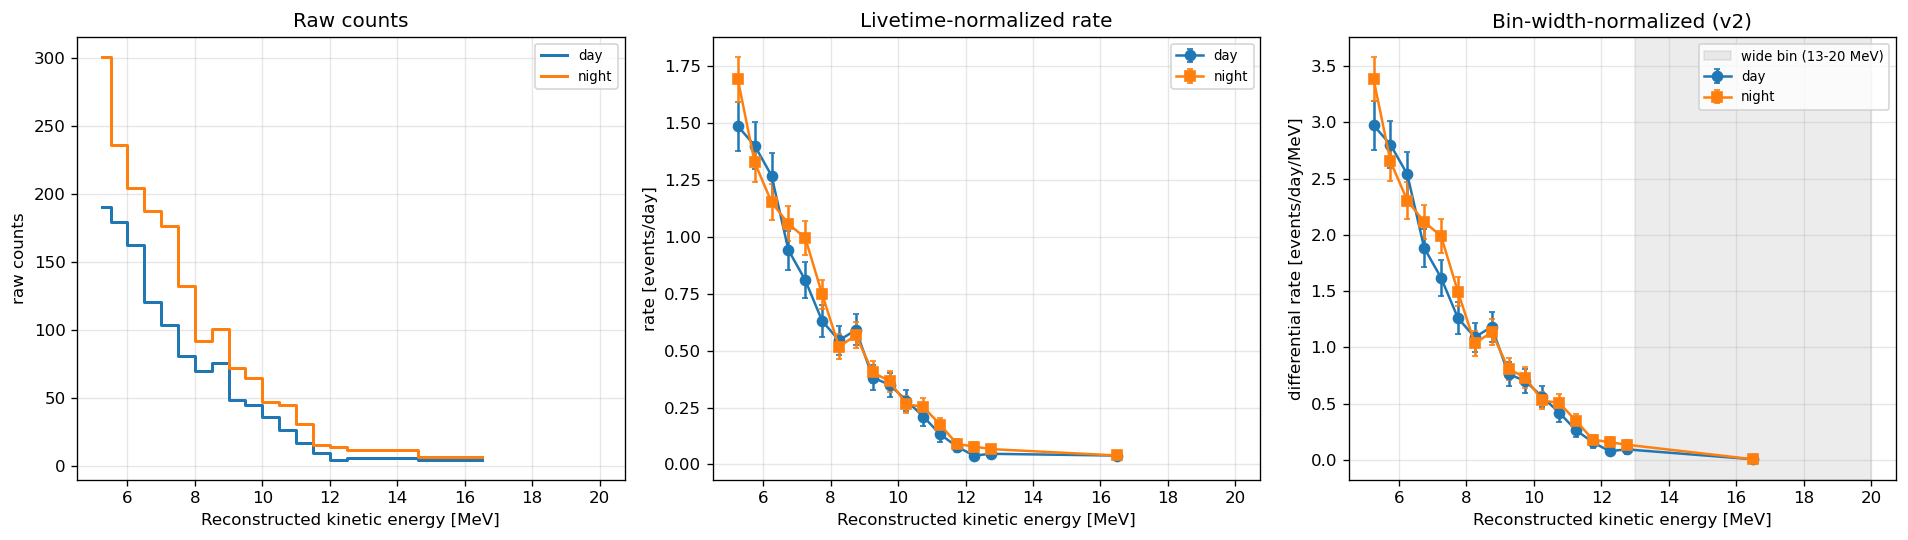

v:\output\external\SNO\SNO_EDA_v2_fig4_1_day_night_spectra_rates.png
raw count in widest bin (17)         : day=5, night=7
differential rate in widest bin (17) : day=0.0056, night=0.0056 events/day/MeV
differential rate in bin 1 (narrow)  : day=2.9728, night=3.3839 events/day/MeV


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16.0, 4.6), sharex=True)

axes[0].step(spectra["Tmid"], spectra["Nday"], where="mid", lw=1.8, label="day")
axes[0].step(spectra["Tmid"], spectra["Nnight"], where="mid", lw=1.8, label="night")
axes[0].set_ylabel("raw counts")
axes[0].set_title("Raw counts")

axes[1].errorbar(combined["Tmid"], combined["day_rate_per_day"], yerr=combined["day_rate_err"], fmt="o-", capsize=2, label="day")
axes[1].errorbar(combined["Tmid"], combined["night_rate_per_day"], yerr=combined["night_rate_err"], fmt="s-", capsize=2, label="night")
axes[1].set_ylabel("rate [events/day]")
axes[1].set_title("Livetime-normalized rate")

axes[2].errorbar(combined["Tmid"], combined["day_diff_rate"], yerr=combined["day_diff_rate_err"], fmt="o-", capsize=2, label="day")
axes[2].errorbar(combined["Tmid"], combined["night_diff_rate"], yerr=combined["night_diff_rate_err"], fmt="s-", capsize=2, label="night")
axes[2].axvspan(13.0, 20.0, color="gray", alpha=0.15, label="wide bin (13-20 MeV)")
axes[2].set_ylabel("differential rate [events/day/MeV]")
axes[2].set_title("Bin-width-normalized (v2)")

for ax in axes:
    ax.set_xlabel("Reconstructed kinetic energy [MeV]")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

fig.tight_layout()
save_and_show("SNO_EDA_v2_fig4_1_day_night_spectra_rates.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print(f"raw count in widest bin (17)         : day={int(spectra.iloc[-1]['Nday'])}, night={int(spectra.iloc[-1]['Nnight'])}")
print(f"differential rate in widest bin (17) : day={combined.iloc[-1]['day_diff_rate']:.4f}, night={combined.iloc[-1]['night_diff_rate']:.4f} events/day/MeV")
print(f"differential rate in bin 1 (narrow)  : day={combined.iloc[0]['day_diff_rate']:.4f}, night={combined.iloc[0]['night_diff_rate']:.4f} events/day/MeV")

### 4.2 Day/Night Asymmetry

For a compact EDA diagnostic, define the bin-wise rate asymmetry as

$$
A_{ND} = \frac{R_N - R_D}{(R_N + R_D)/2}.
$$

The uncertainty shown is a simple Poisson propagation from raw counts and
should be interpreted as an exploratory diagnostic rather than the full SNO
likelihood treatment used in `nucl-ex/0204009` to extract the official
day/night asymmetry and its constraint on neutrino mixing parameters.

**Expected results:** the bin-wise values should fluctuate with sizeable
uncertainties, especially at high energy where counts are low, and should be
statistically consistent with zero given those uncertainties.

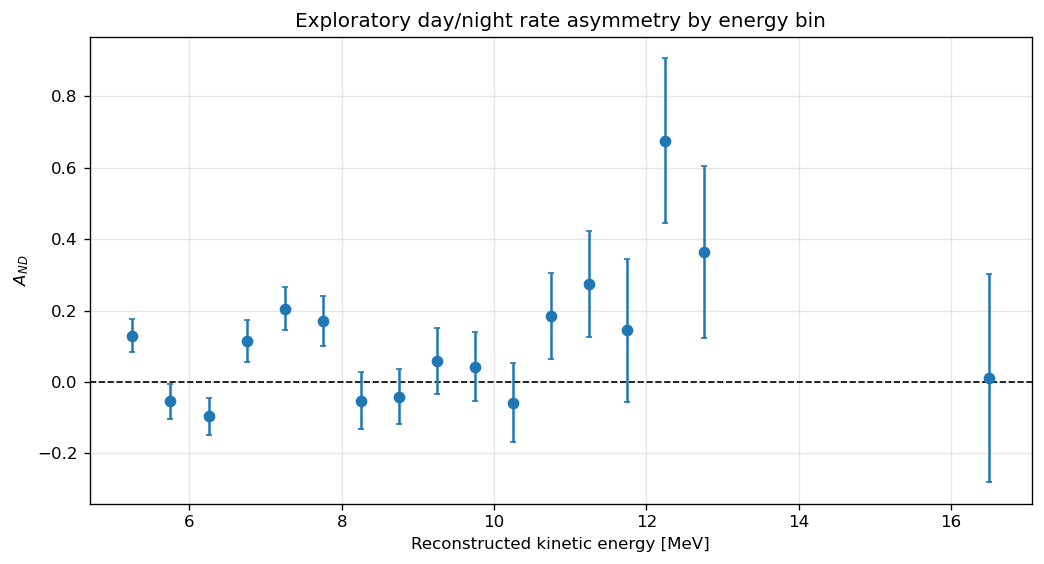

v:\output\external\SNO\SNO_EDA_v2_fig4_2_day_night_asymmetry.png


,bin,Tmin,Tmax,day_rate_per_day,night_rate_per_day,night_day_asymmetry,asymmetry_err_approx
0,1,5.0,5.5,1.486381,1.691962,0.129363,0.046061
1,2,5.5,6.0,1.400778,1.326588,-0.054404,0.049443
2,3,6.0,6.5,1.268482,1.152333,-0.095959,0.052351
3,4,6.5,7.0,0.941634,1.056773,0.115231,0.058081
4,5,7.0,7.5,0.809339,0.994941,0.205736,0.061122
5,6,7.5,8.0,0.630350,0.747611,0.170195,0.069960
6,7,8.0,8.5,0.544747,0.517144,-0.051988,0.079248
7,8,8.5,9.0,0.591440,0.567735,-0.040900,0.075894
8,9,9.0,9.5,0.381323,0.404722,0.059536,0.092515
9,10,9.5,10.0,0.350195,0.365374,0.042426,0.096919


error-weighted mean bin-wise asymmetry (exploratory only): 0.0588


In [16]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.axhline(0.0, color="black", lw=1.0, ls="--")
ax.errorbar(
    combined["Tmid"],
    combined["night_day_asymmetry"],
    yerr=combined["asymmetry_err_approx"],
    fmt="o",
    capsize=2,
)
ax.set_xlabel("Reconstructed kinetic energy [MeV]")
ax.set_ylabel(r"$A_{ND}$")
ax.set_title("Exploratory day/night rate asymmetry by energy bin")
ax.grid(True, alpha=0.3)
fig.tight_layout()
save_and_show("SNO_EDA_v2_fig4_2_day_night_asymmetry.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

display(combined[["bin", "Tmin", "Tmax", "day_rate_per_day", "night_rate_per_day", "night_day_asymmetry", "asymmetry_err_approx"]])

weighted_asymmetry = float(np.average(combined["night_day_asymmetry"], weights=1.0 / combined["asymmetry_err_approx"]**2))
print(f"error-weighted mean bin-wise asymmetry (exploratory only): {weighted_asymmetry:.4f}")

## 5. Background Tables and Signal Estimate

This section covers the tabulated neutron and low-energy backgrounds (5.1)
and the resulting background-subtracted differential signal rate (5.2), both
derived from `SnoBackgroundTables.dat` combined with the Section 4 spectra.

### 5.1 Background Tables

The background table gives neutron and low-energy background estimates and
uncertainties for each energy bin and for day/night samples separately.

**Expected results:** low-energy backgrounds should be largest near threshold
and rapidly decrease with increasing energy; neutron backgrounds fall off
more gradually. Background fractions should be most important in the first
bin.

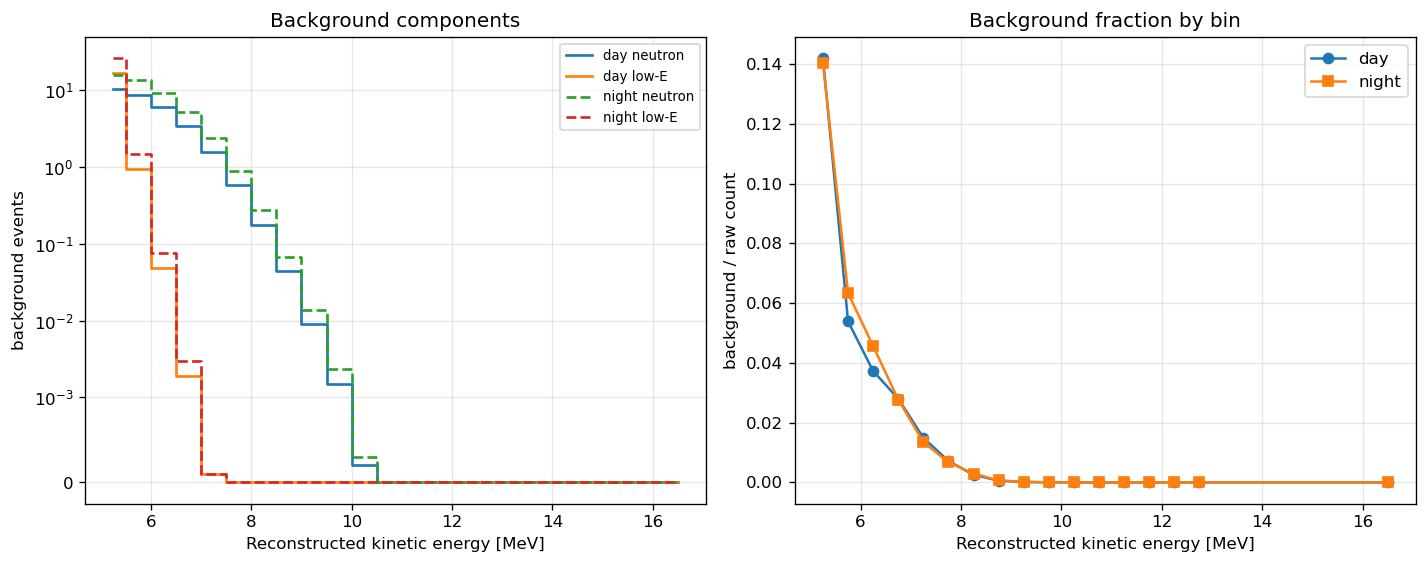

v:\output\external\SNO\SNO_EDA_v2_fig5_1_backgrounds.png


,bin,Tmin,Tmax,day_total_bg,night_total_bg,day_bg_fraction,night_bg_fraction
0,1,5.0,5.5,27.1053,42.2406,0.141913,0.140334
1,2,5.5,6.0,9.6983,14.9528,0.053879,0.063359
2,3,6.0,6.5,6.0765,9.3515,0.037279,0.045617
3,4,6.5,7.0,3.3886,5.2142,0.028005,0.027735
4,5,7.0,7.5,1.5533,2.3900,0.014936,0.013503
5,6,7.5,8.0,0.5815,0.8947,0.007179,0.006727
6,7,8.0,8.5,0.1777,0.2735,0.002539,0.002973
7,8,8.5,9.0,0.0443,0.0682,0.000583,0.000675
8,9,9.0,9.5,0.0090,0.0139,0.000184,0.000193
9,10,9.5,10.0,0.0015,0.0023,0.000033,0.000035


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8), sharex=True)

axes[0].step(combined["Tmid"], combined["day_NBg"], where="mid", label="day neutron", lw=1.6)
axes[0].step(combined["Tmid"], combined["day_LEBg"], where="mid", label="day low-E", lw=1.6)
axes[0].step(combined["Tmid"], combined["night_NBg"], where="mid", label="night neutron", lw=1.6, ls="--")
axes[0].step(combined["Tmid"], combined["night_LEBg"], where="mid", label="night low-E", lw=1.6, ls="--")
axes[0].set_yscale("symlog", linthresh=1.0e-3)
axes[0].set_xlabel("Reconstructed kinetic energy [MeV]")
axes[0].set_ylabel("background events")
axes[0].set_title("Background components")
axes[0].grid(True, alpha=0.3)
axes[0].legend(fontsize=8)

axes[1].plot(combined["Tmid"], combined["day_bg_fraction"], "o-", label="day")
axes[1].plot(combined["Tmid"], combined["night_bg_fraction"], "s-", label="night")
axes[1].set_xlabel("Reconstructed kinetic energy [MeV]")
axes[1].set_ylabel("background / raw count")
axes[1].set_title("Background fraction by bin")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
save_and_show("SNO_EDA_v2_fig5_1_backgrounds.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

display(combined[["bin", "Tmin", "Tmax", "day_total_bg", "night_total_bg", "day_bg_fraction", "night_bg_fraction"]])

### 5.2 Background-Subtracted Differential Rate

Subtracting the tabulated neutron and low-energy backgrounds gives a simple
signal-count estimate per bin, again shown as a bin-width-normalized
differential rate for the same reason as Section 4.1. This is not a replacement
for the SNO spectral fit, but it is useful for checking the relative scale of
the tabulated backgrounds against the differential signal shape.

**Expected results:** the background-subtracted differential spectra should
remain positive in all bins and should be close to the raw differential rate
except near the low-energy threshold, where backgrounds are largest.

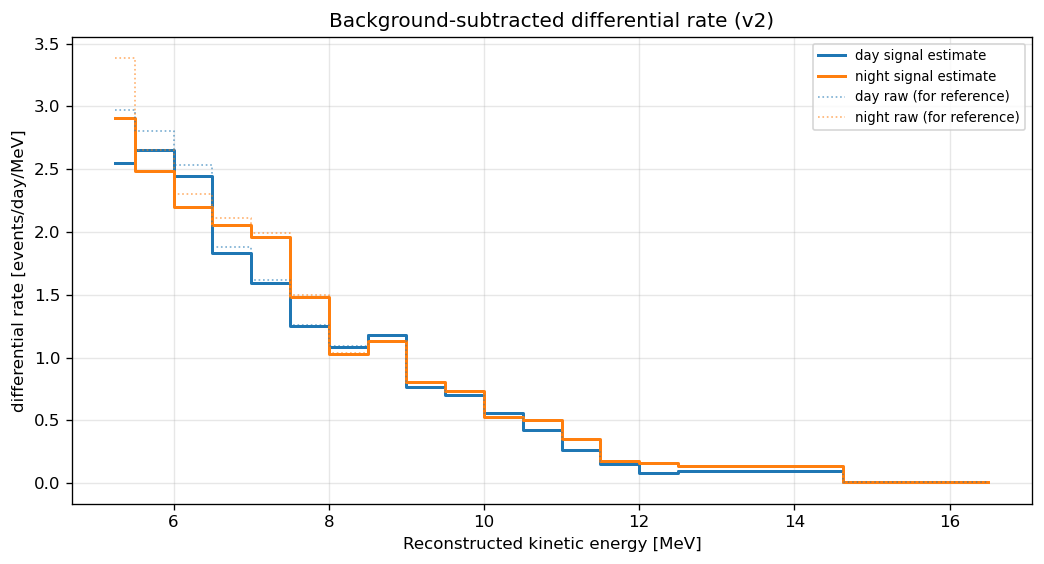

v:\output\external\SNO\SNO_EDA_v2_fig5_2_background_subtracted_diff_rate.png
minimum day signal estimate  : 5.0
minimum night signal estimate: 7.0


In [18]:
fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.step(combined["Tmid"], combined["day_signal_diff_rate"], where="mid", lw=1.8, label="day signal estimate")
ax.step(combined["Tmid"], combined["night_signal_diff_rate"], where="mid", lw=1.8, label="night signal estimate")
ax.step(combined["Tmid"], combined["day_diff_rate"], where="mid", lw=1.0, ls=":", color="C0", alpha=0.6, label="day raw (for reference)")
ax.step(combined["Tmid"], combined["night_diff_rate"], where="mid", lw=1.0, ls=":", color="C1", alpha=0.6, label="night raw (for reference)")
ax.set_xlabel("Reconstructed kinetic energy [MeV]")
ax.set_ylabel("differential rate [events/day/MeV]")
ax.set_title("Background-subtracted differential rate (v2)")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
fig.tight_layout()
save_and_show("SNO_EDA_v2_fig5_2_background_subtracted_diff_rate.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

print("minimum day signal estimate  :", float(combined["day_signal_est"].min()))
print("minimum night signal estimate:", float(combined["night_signal_est"].min()))

## 6. Combined Spectrum and Shape Comparison

Two further exploratory views: the total (day+night) differential spectrum,
and a **shape-only** comparison where each of the day and night differential
spectra is separately normalized to unit area. The shape comparison isolates
spectral *distortion* from the overall day/night rate difference already
explored in Section 4 (which is dominated by the different day/night
exposure).

**Expected results:** the total spectrum should fall smoothly with energy;
the unit-area-normalized day and night shapes should overlap closely, since
any percent-level MSW spectral distortion is far smaller than the bin-wise
statistical uncertainties of this exploratory dataset.

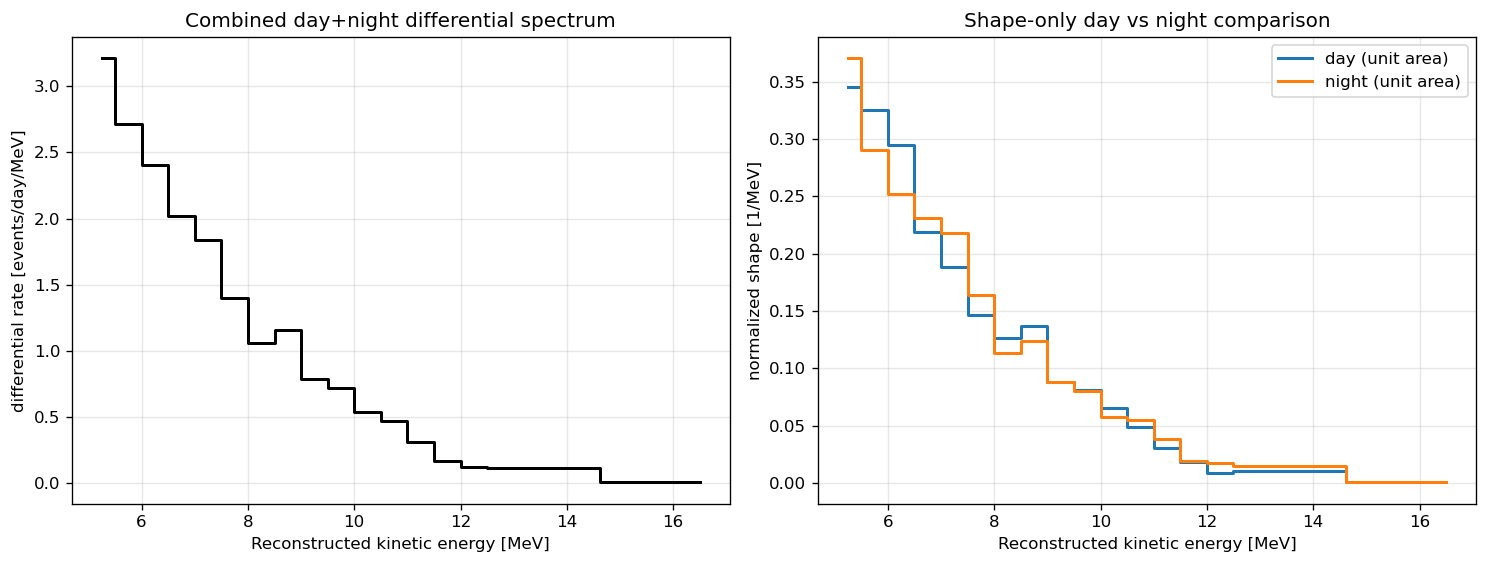

v:\output\external\SNO\SNO_EDA_v2_fig6_1_combined_and_shape.png
max |day_shape - night_shape| (unit-area normalized): 0.0424 per MeV


In [19]:
total_diff_rate = combined["day_diff_rate"] * livetimes["day_days"] + combined["night_diff_rate"] * livetimes["night_days"]
total_diff_rate = total_diff_rate / (livetimes["day_days"] + livetimes["night_days"])

day_shape = combined["day_diff_rate"] /numpy_trapezoid(combined["day_diff_rate"], combined["Tmid"])
night_shape = combined["night_diff_rate"] / numpy_trapezoid(combined["night_diff_rate"], combined["Tmid"])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharex=True)

axes[0].step(combined["Tmid"], total_diff_rate, where="mid", lw=1.8, color="black")
axes[0].set_ylabel("differential rate [events/day/MeV]")
axes[0].set_title("Combined day+night differential spectrum")

axes[1].step(combined["Tmid"], day_shape, where="mid", lw=1.8, label="day (unit area)")
axes[1].step(combined["Tmid"], night_shape, where="mid", lw=1.8, label="night (unit area)")
axes[1].set_ylabel("normalized shape [1/MeV]")
axes[1].set_title("Shape-only day vs night comparison")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("Reconstructed kinetic energy [MeV]")
    ax.grid(True, alpha=0.3)

fig.tight_layout()
save_and_show("SNO_EDA_v2_fig6_1_combined_and_shape.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

shape_diff = float(np.max(np.abs(day_shape - night_shape)))
print(f"max |day_shape - night_shape| (unit-area normalized): {shape_diff:.4f} per MeV")

## 7. Livetime versus Cosine Zenith

The cos-zenith table contains the detector livetime in seconds for 480
equal-width bins between $\cos\theta_z=-1$ and $+1$.

**Expected results:** the total livetime should match the day plus night
livetime from the spectra header to within rounding. Empty bins near the
edges are expected from the detector latitude, solar path, and binning
convention.

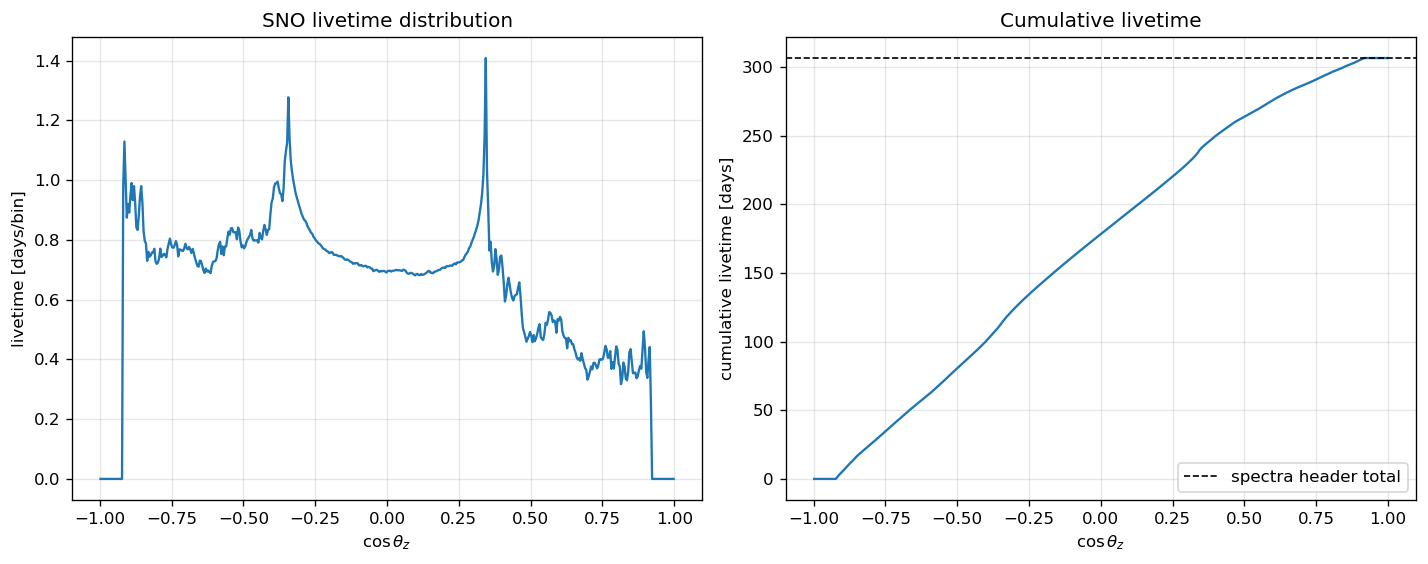

v:\output\external\SNO\SNO_EDA_v2_fig7_1_coszenith_livetime.png


,quantity,value
0,cos-zenith table bins,480.000000
1,cos-zenith total days,306.391091
2,spectra header total days,306.400000
3,difference days,-0.008909
4,nonzero cos-zenith bins,442.000000


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.8))

axes[0].plot(coszenith["cosz_mid"], coszenith["livetime_days"], lw=1.4)
axes[0].set_xlabel(r"$\cos\theta_z$")
axes[0].set_ylabel("livetime [days/bin]")
axes[0].set_title("SNO livetime distribution")
axes[0].grid(True, alpha=0.3)

cumulative = coszenith["livetime_days"].cumsum()
axes[1].plot(coszenith["cosz_mid"], cumulative, lw=1.4)
axes[1].axhline(livetimes["day_days"] + livetimes["night_days"], color="black", lw=1.0, ls="--", label="spectra header total")
axes[1].set_xlabel(r"$\cos\theta_z$")
axes[1].set_ylabel("cumulative livetime [days]")
axes[1].set_title("Cumulative livetime")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

fig.tight_layout()
save_and_show("SNO_EDA_v2_fig7_1_coszenith_livetime.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

livetime_check = pd.DataFrame([
    {"quantity": "cos-zenith table bins", "value": len(coszenith)},
    {"quantity": "cos-zenith total days", "value": coszenith["livetime_days"].sum()},
    {"quantity": "spectra header total days", "value": livetimes["day_days"] + livetimes["night_days"]},
    {"quantity": "difference days", "value": coszenith["livetime_days"].sum() - (livetimes["day_days"] + livetimes["night_days"])},
    {"quantity": "nonzero cos-zenith bins", "value": int((coszenith["livetime_s"] > 0).sum())},
])
display(livetime_check)

## 8. Combined Diagnostics

This section combines the energy spectra and background tables into compact
summary views.

**Expected results:** total raw counts and background estimates should be
dominated by the lowest energy bins, while the high-energy tail should have
low statistics.

,sample,raw_counts,background_est,signal_est,livetime_days,raw_rate_per_day,signal_rate_per_day,background_fraction
0,day,1186,48.6362,1137.3638,128.5,9.229572,8.851080,0.041009
1,night,1742,75.4020,1666.5980,177.9,9.792018,9.368173,0.043285


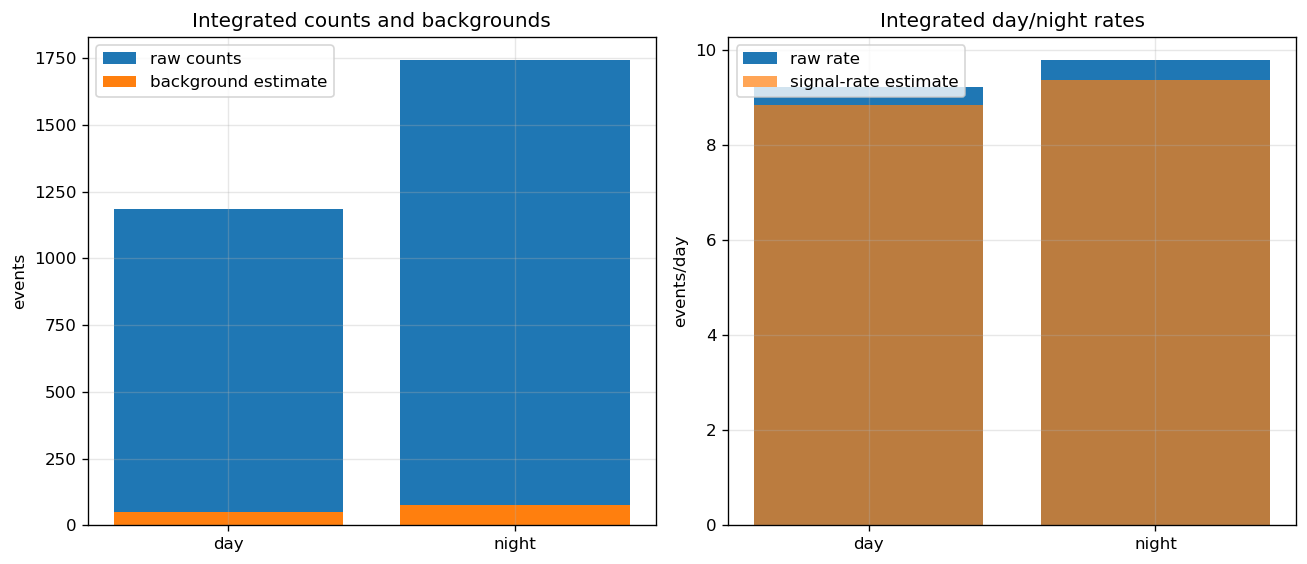

v:\output\external\SNO\SNO_EDA_v2_fig8_1_integrated_diagnostics.png


In [21]:
total_rows = pd.DataFrame([
    {"sample": "day", "raw_counts": spectra["Nday"].sum(), "background_est": combined["day_total_bg"].sum(), "signal_est": combined["day_signal_est"].sum(), "livetime_days": livetimes["day_days"]},
    {"sample": "night", "raw_counts": spectra["Nnight"].sum(), "background_est": combined["night_total_bg"].sum(), "signal_est": combined["night_signal_est"].sum(), "livetime_days": livetimes["night_days"]},
])
total_rows["raw_rate_per_day"] = total_rows["raw_counts"] / total_rows["livetime_days"]
total_rows["signal_rate_per_day"] = total_rows["signal_est"] / total_rows["livetime_days"]
total_rows["background_fraction"] = total_rows["background_est"] / total_rows["raw_counts"]
display(total_rows)

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.8))
axes[0].bar(total_rows["sample"], total_rows["raw_counts"], label="raw counts")
axes[0].bar(total_rows["sample"], total_rows["background_est"], label="background estimate")
axes[0].set_ylabel("events")
axes[0].set_title("Integrated counts and backgrounds")
axes[0].grid(True, axis="y", alpha=0.3)
axes[0].legend()

axes[1].bar(total_rows["sample"], total_rows["raw_rate_per_day"], label="raw rate")
axes[1].bar(total_rows["sample"], total_rows["signal_rate_per_day"], alpha=0.7, label="signal-rate estimate")
axes[1].set_ylabel("events/day")
axes[1].set_title("Integrated day/night rates")
axes[1].grid(True, axis="y", alpha=0.3)
axes[1].legend()

fig.tight_layout()
save_and_show("SNO_EDA_v2_fig8_1_integrated_diagnostics.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

## 9. Summary

The local `data/external/SNO` files reproduce the compact public data release
associated with the SNO NC and day/night PRL analyses
([sno.phy.queensu.ca/sno/prlwebpage](https://sno.phy.queensu.ca/sno/prlwebpage/),
Ahmad et al. 2002, `nucl-ex/0204008` and `nucl-ex/0204009`). The spectra and
background tables share 17 kinetic-energy bins (16 of width 0.5 MeV plus one
wide 13-20 MeV bin), while the cos-zenith livetime file provides 480 exposure
bins over $\cos\theta_z\in[-1,1]$.

The EDA confirms the basic structure of the data: night has more raw events
because the night exposure is longer; after livetime normalization, day and
night rates are comparable within large bin-wise statistical uncertainties,
and the exploratory day/night asymmetry is consistent with zero at this
precision. Backgrounds are concentrated near the 5 MeV threshold and become
negligible above roughly 8 MeV. The cos-zenith livetime sum agrees with the
total day plus night exposure quoted in the spectra header to the expected
rounding precision.

**What v2 adds over v1:** correcting for the 14x-wider final energy bin (via
the differential rate events/day/MeV) shows that its apparently small raw
count is consistent with the same falling spectral trend as the narrower
bins, not a separate feature; and the unit-area shape comparison in Section 6
isolates spectral distortion from the day/night exposure difference, showing
the two shapes overlap closely at this statistical precision.

These tables are suitable for downstream validation notebooks that need SNO
day/night spectral counts, approximate background corrections, or
zenith-exposure weights. A full SNO oscillation-parameter analysis would
require the collaboration's likelihood machinery and detector-response
treatment beyond this lightweight EDA.